# Bias-Variance Tradeoff and Learning Curves

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand bias and variance in machine learning
- Analyze bias-variance tradeoff through learning curves
- Identify and handle overfitting/underfitting
- Select optimal model complexity using validation sets

## 🔗 Where this fits

**Builds on:** Course 04 — Unit 1, lesson 05 "Polynomial Regression" and Unit 2, lesson 01 "Cross-Validation" — degree sets model complexity, cross-validation measures what it costs.

**Used later in:** Course 04 — Unit 5, where model selection is exactly the search for the right point on this curve.

---

This notebook covers practical activities from **Course 04, Unit 2**:
- Analyzing bias-variance tradeoff through learning curves
- Identifying and handling overfitting/underfitting
- Selecting optimal model complexity using validation sets

---

## Introduction to Bias-Variance Tradeoff

**Bias**: Error from overly simplistic assumptions (underfitting)
**Variance**: Error from sensitivity to small fluctuations (overfitting)
**Tradeoff**: Finding the right balance between model complexity and generalization


## 🌍 A real case: when more data beat a better algorithm

In 2001 Michele Banko and Eric Brill (Microsoft Research) trained four different learners on the same
language task — picking the right word from a confusable set — using training corpora that grew from
one million words to **one billion**. Their learning curves never flattened. More striking, the
*ranking of the algorithms changed with data size*: a learner that was clearly worst on a million
words overtook the others once it had a billion ("Scaling to Very Very Large Corpora for Natural
Language Disambiguation", ACL 2001).

**❗ Why this lesson exists.** Two teams can be stuck at the same error and need opposite things.
Read the numbers this notebook prints:

| Model | Train MSE | Val MSE | Gap |
|---|---|---|---|
| Degree 1 | 8.15 | 9.36 | 1.21 |
| Degree 4 | 1.24 | 1.68 | 0.44 |
| Degree 15 | 0.89 | 20.86 | **19.97** |

Degree 1 is bad on data it has *already seen* — more data cannot help a model that cannot represent
the curve. Degree 15 is nearly perfect on training data and useless on validation — more data is the
one thing that would help it. Same dataset, opposite prescriptions, and a single accuracy number
cannot tell them apart. The learning curve can.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- `../../datasets/raw/montgomery_911_calls.csv` — the real dispatch log you met in Unit 1, here at
  half-hour resolution: 48 points giving the average number of 911 calls in each half-hour of the day

**Outputs:** What you'll see when you run the cells

- Learning curves for three model complexities, a computed underfit/good-fit/overfit diagnosis
  for each, and the degree that minimizes validation error.

---

In [1]:
# CELL: Import the tools for this lesson.
# WHY: learning_curve() does the heavy lifting - it retrains a model on
# growing slices of data so we can watch bias and variance appear.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [2]:
# Build the dataset from a REAL emergency dispatch log (Montgomery County, PA).
# WHY real: on invented data you can print the exact noise floor and grade models against
# it. Real data gives you no such number — you have to diagnose bias and variance from the
# learning curves alone, which is the skill this notebook is actually teaching.
calls = pd.read_csv("../../datasets/raw/montgomery_911_calls.csv",
                    usecols=["timeStamp"], nrows=400_000)
stamps = pd.to_datetime(calls["timeStamp"], errors="coerce").dropna()

# Use the first 30 days of the log, bucketed into half-hour slots of the day.
days = sorted(stamps.dt.date.unique())[:30]
window = stamps[stamps.dt.date.isin(days)]
slot = (window.dt.hour * 60 + window.dt.minute) // 30      # 0..47

per_day_slot = (pd.DataFrame({"date": window.dt.date, "slot": slot})
                .groupby(["date", "slot"]).size().reset_index(name="calls"))
profile = per_day_slot.groupby("slot")["calls"].mean().reset_index()

X = (profile[["slot"]].to_numpy(dtype=float) * 0.5)   # hour of day, 0.0 .. 23.5
y = profile["calls"].to_numpy(dtype=float)            # average calls in that half hour

print(f"Samples: {X.shape[0]} half-hour slots   Period: {days[0]} to {days[-1]}")
print(f"Feature range: hour {X.min():.1f} to {X.max():.1f}")
print(f"Target range: [{y.min():.2f}, {y.max():.2f}] average calls, variance {y.var():.3f}")
print("There is no known noise floor here — the day-to-day randomness in a county's")
print("emergencies is whatever it is. We will have to infer it from the curves.")

Samples: 48 half-hour slots   Period: 2015-12-10 to 2016-01-08
Feature range: hour 0.0 to 23.5
Target range: [2.44, 15.37] average calls, variance 11.736
There is no known noise floor here — the day-to-day randomness in a county's
emergencies is whatever it is. We will have to infer it from the curves.


## Part 1: Learning Curves - Analyzing Model Performance

**A quick note on `Pipeline`** (new sklearn object): `Pipeline([('poly', PolynomialFeatures(...)), ('linear', LinearRegression())])` chains a transform step and a model into ONE object that behaves like a single model (`fit`/`predict`). We need it because `learning_curve` refits the model many times on different folds - the pipeline guarantees the polynomial features are recomputed inside every fold from that fold's training data only (no leakage between folds).


Degree 1:
  Final train MSE: 8.1450
  Final val MSE:   9.3595
Degree 4:
  Final train MSE: 1.2383
  Final val MSE:   1.6753
Degree 15:
  Final train MSE: 0.8894
  Final val MSE:   20.8578

Note: the y-axis is logarithmic and clipped to [0.01, 1000] - the degree-4 and
degree-15 validation errors on the smallest training sets are far above the top.


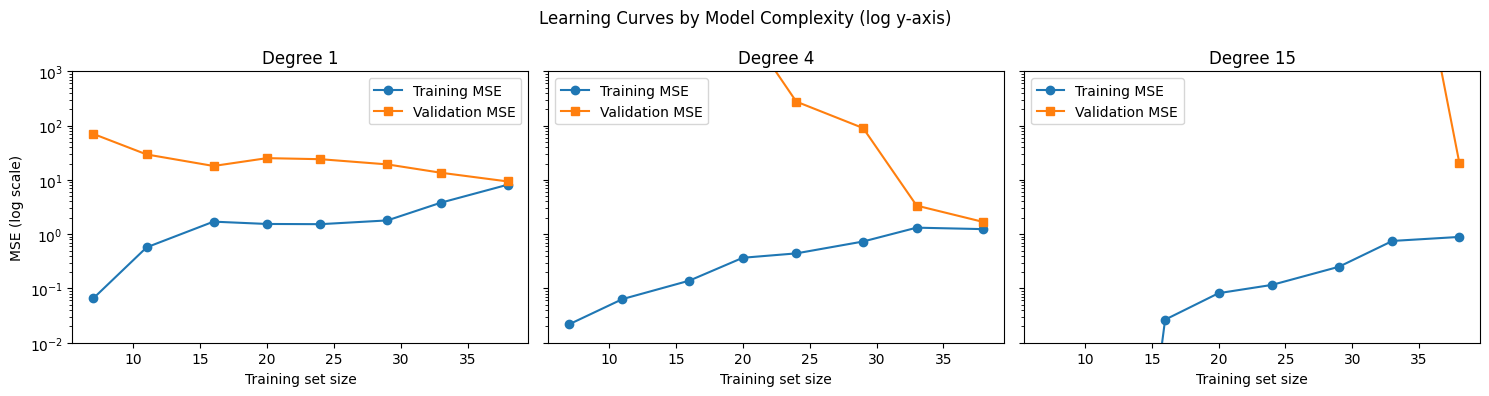

In [3]:
# Create learning curves for different model complexities
#
# NOTE on cross-validation: our X values are SORTED (hour 0 -> 23.5) and
# learning_curve does not shuffle by default. Unshuffled folds would hold out
# a contiguous chunk of the x-range, forcing the model to EXTRAPOLATE far
# outside its training range - that measures extrapolation, not generalization.
# A shuffled KFold gives every fold a representative slice of the x-range.
cv = KFold(n_splits=5, shuffle=True, random_state=42)

degrees = [1, 4, 15]
models = {}

for degree in degrees:
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree)),
        ('linear', LinearRegression())
    ])

    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=cv, n_jobs=-1,
        train_sizes=np.linspace(0.2, 1.0, 8),
        scoring='neg_mean_squared_error'
    )

    models[degree] = {
        'train_sizes': train_sizes,
        'train_mean': -train_scores.mean(axis=1), 'train_std': train_scores.std(axis=1),
        'val_mean': -val_scores.mean(axis=1), 'val_std': val_scores.std(axis=1)
    }

    print(f"Degree {degree}:")
    print(f"  Final train MSE: {models[degree]['train_mean'][-1]:.4f}")
    print(f"  Final val MSE:   {models[degree]['val_mean'][-1]:.4f}")

# Plot the three learning curves side by side on a LOG y-axis.
# WHY log: on tiny training sets a high-degree polynomial swings wildly between the few
# points it has seen, so its validation MSE reaches astronomical values. A linear axis
# would either hide the explosion or flatten everything else into a single line.
print("\nNote: the y-axis is logarithmic and clipped to [0.01, 1000] - the degree-4 and")
print("degree-15 validation errors on the smallest training sets are far above the top.")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, degree in zip(axes, degrees):
    m = models[degree]
    ax.plot(m['train_sizes'], m['train_mean'], 'o-', label='Training MSE')
    ax.plot(m['train_sizes'], m['val_mean'], 's-', label='Validation MSE')
    ax.set_title(f'Degree {degree}')
    ax.set_xlabel('Training set size')
    ax.set_yscale('log')
    ax.set_ylim(1e-2, 1e3)
    ax.legend()
axes[0].set_ylabel('MSE (log scale)')
plt.suptitle('Learning Curves by Model Complexity (log y-axis)')
plt.tight_layout()
plt.show()

## Part 2: Identifying Overfitting and Underfitting

We now classify each model as **underfitting**, **good fit**, or **overfitting**.

The labels below are **computed from the measured errors** with explicit
thresholds - not written by hand - so the printed interpretation always
matches the numbers.

One thing changes when the data is real: we no longer know the irreducible error, because
nobody generated these call volumes from a formula. So we use the **best validation MSE any
of our candidate models achieved** as a practical stand-in for "as good as it gets on this
data". Be aware of what that costs us: the best model is graded against itself, so it can
never be labelled underfitting. That is an honest limitation of working without ground
truth, not a trick - and it is the normal situation outside a textbook.

In [4]:
# Bias-variance diagnosis - labels are COMPUTED from the measured MSE values,
# so the printed interpretation can never disagree with the numbers.

# Best validation MSE across our candidates: our empirical stand-in for the
# irreducible error, since real data comes with no stated noise level.
REFERENCE_MSE = min(models[d]['val_mean'][-1] for d in degrees)

def diagnose(train_mse, val_mse):
    """Classify fit quality from final train/validation MSE.

    Rules (checked in order):
      1. OVERFITTING:  val > 2 x train AND gap > reference
                       (validation error far above training error)
      2. UNDERFITTING: val > 3 x reference
                       (even validation error is far above the best we achieved)
      3. GOOD FIT:     otherwise (both errors low and close together)
    """
    gap = val_mse - train_mse
    if val_mse > 2 * train_mse and gap > REFERENCE_MSE:
        return "OVERFITTING (high variance)"
    if val_mse > 3 * REFERENCE_MSE:
        return "UNDERFITTING (high bias)"
    return "GOOD FIT (balanced bias-variance)"

print("=" * 60)
print("Bias-Variance Analysis (labels computed from the numbers)")
print("=" * 60)
print(f"Reference MSE (best validation error achieved): {REFERENCE_MSE:.3f}")
print(f"For scale, predicting the overall average every time scores MSE {y.var():.3f}")

for degree in degrees:
    train_mse = models[degree]['train_mean'][-1]
    val_mse = models[degree]['val_mean'][-1]
    gap = val_mse - train_mse
    label = diagnose(train_mse, val_mse)
    print(f"\nDegree {degree}:")
    print(f"  Train MSE: {train_mse:.4f}")
    print(f"  Val MSE:   {val_mse:.4f}")
    print(f"  Gap:       {gap:.4f}")
    print(f"  Diagnosis: {label}")

# Pick the optimal complexity by validation error
best_degree = min(models, key=lambda d: models[d]['val_mean'][-1])
best_label = diagnose(models[best_degree]['train_mean'][-1],
                      models[best_degree]['val_mean'][-1])
print("\n" + "=" * 60)
print(f"Optimal model complexity by validation MSE: degree {best_degree}")
print(f"Its computed diagnosis: {best_label}")
print("=" * 60)

Bias-Variance Analysis (labels computed from the numbers)
Reference MSE (best validation error achieved): 1.675
For scale, predicting the overall average every time scores MSE 11.736

Degree 1:
  Train MSE: 8.1450
  Val MSE:   9.3595
  Gap:       1.2146
  Diagnosis: UNDERFITTING (high bias)

Degree 4:
  Train MSE: 1.2383
  Val MSE:   1.6753
  Gap:       0.4370
  Diagnosis: GOOD FIT (balanced bias-variance)

Degree 15:
  Train MSE: 0.8894
  Val MSE:   20.8578
  Gap:       19.9684
  Diagnosis: OVERFITTING (high variance)

Optimal model complexity by validation MSE: degree 4
Its computed diagnosis: GOOD FIT (balanced bias-variance)


## 💬 Discuss

1. **You have budget for exactly one of:** (a) collecting three more months of dispatch data, or
   (b) trying a different family of model. Which do you buy for the degree-1 model, which for the
   degree-15 model, and what in the table above forces each choice?

2. **Predicting the overall average scores MSE 11.74. Degree 1 scores 9.36.** Better — but not by
   much, for all the work. At what point is a model "not worth having" compared with a constant?
   Commit to a rule and defend it against someone who says any improvement is an improvement.

3. **This dataset is 48 half-hour slots.** The degree-15 validation error on the smallest training
   sets runs off the top of a log-scaled plot. Is that a fact about degree-15 polynomials, or a fact
   about having 48 rows? Design the check that would tell the two apart.

## ⚠️ Where this breaks

- **The diagnosis is only as fair as the validation set.** These 48 slots cover 10 December 2015 to
  8 January 2016 — one holiday period. A model labelled "good fit" on this window can be badly biased
  in July, and the learning curve will not say so.
- **Learning curves are expensive.** They refit the model at every training size, for every fold. With
  a model that takes hours to train, a single train-versus-validation gap at full data size answers
  the "more data or better model?" question at a fraction of the cost.
- **The assumption that must hold:** the new data would come from the same process as the old. If you
  can only obtain *different* data — another county, another year — the curve's promise that more data
  helps does not transfer.
- **What the curve cannot tell you:** whether the *features* are right. A curve that is flat and high
  for every model size means your columns do not carry the signal. No amount of extra rows or extra
  model capacity fixes a measurement you did not take.


## Summary

### Key Concepts:
1. **Bias**: Model too simple, cannot capture patterns (underfitting)
2. **Variance**: Model too complex, memorizes noise (overfitting)
3. **Learning Curves**: Show train/validation performance vs training set size
4. **Optimal Complexity**: Balance where validation error is minimized

### How to Use:
- **Large gap between train/val**: Overfitting → reduce complexity
- **Both train/val high**: Underfitting → increase complexity
- **Both train/val similar and low**: Good model
- **No known noise floor**: on real data, compare candidates against each other and against
  the trivial "predict the mean" baseline, and watch the shape of the curves — a validation
  curve still falling at the right-hand edge means *more data would help*; one that has
  flattened far above the training curve means *a different model would help*.

**Reference:** Course 04, Unit 2: "Analyzing bias-variance tradeoff through learning curves" and "Identifying and handling overfitting/underfitting"


## 📚 References

1. Geman, S., Bienenstock, E., & Doursat, R. (1992). *Neural Networks and the Bias/Variance Dilemma*. Neural Computation, 4(1), 1–58.
2. Belkin, M., Hsu, D., Ma, S., & Mandal, S. (2019). *Reconciling Modern Machine Learning Practice and the Bias-Variance Trade-off*. PNAS, 116(32). <https://arxiv.org/abs/1812.11118>
3. Viering, T., & Loog, M. (2023). *The Shape of Learning Curves: A Review*. IEEE Transactions on Pattern Analysis and Machine Intelligence, 45(6). <https://arxiv.org/abs/2103.10948>
